# EDA 


In [2]:
#Import all the libraries

import pandas as pd
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from sklearn.feature_extraction.text import TfidfVectorizer #Vecctorizing Text


In [3]:
#Import the Finalised dataset from step 1
df = pd.read_csv("Datasets/Finalized_Dataset.csv", sep=",", header=0)
print(df.head(5)) # Display the head

                                             content  temperature_2m_mean  \
0  Collision between a car and a motorbike in Żur...             0.103670   
1  Car-motorcycle traffic accident Yesterday, at ...             0.697599   
2  Car-motorcycle collision in Ħal Qormi Today, a...            -0.044812   
3  Collision between motorcycle and car in Għaxaq...             0.827521   
4  Car-motorcycle collision Yesterday, at around ...            -1.047068   

   apparent_temperature_mean  precipitation_sum  precipitation_hours  \
0                   0.148919          -0.204187            -0.579751   
1                   0.877228          -0.154628             0.151526   
2                  -0.007147          -0.204187            -0.579751   
3                   0.734167          -0.204187            -0.579751   
4                  -1.021578           0.060125             0.395285   

   wind_speed_10m_max  is_holiday  year  month  day  tag_National  \
0           -1.258551           0  

## Univariate Analysis

In [4]:
#Analyze the variables Mean, Median, Variance and Standard Deviation - Basic Univariate Analysis

stats_df = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Variance': df.var(numeric_only=True),
    'Standard Deviation': df.std(numeric_only=True)
})

pd.options.display.float_format = '{:.4f}'.format
display(stats_df)

,Mean,Median,Variance,Standard Deviation
temperature_2m_mean,0.0000,0.0651,1.0023,1.0012
apparent_temperature_mean,-0.0000,0.0034,1.0023,1.0012
precipitation_sum,-0.0000,-0.2042,1.0023,1.0012
precipitation_hours,0.0000,-0.5586,1.0023,1.0012
wind_speed_10m_max,-0.0000,-0.1775,1.0023,1.0012
is_holiday,0.0370,0.0000,0.0357,0.1891
year,2024.9097,2025.0000,0.0823,0.2869
month,6.3773,7.0000,10.4861,3.2382
day,15.4329,15.5000,67.6939,8.2276
tag_National,0.7407,1.0000,0.1925,0.4387


### A Quick Look

- For the following variables: 
    - `temperature_2m_mean`,
    - `apparent_temperature_mean`,
    - `precipitation_sum`,
    - `precipitation_hours`,
    - `wind_speed_10m_max`

The mean hovers at $0$ with Variance and Standard Deviation hovering at 1, showing that these values have been standarised properly for training.

The `is_holiday`feature is a weak standalone predictor but from the mean we can tell that around $3.7$% of the rows are holidays.

The `year` feature is almost a constant feature due to the low variance and might have a low predictive value.

The `month` feature shows a good seasonal spread.

The `day` feature is a cyclic feature with a quite a uniform distribution. **It might be better to divide the days in days of the week instead as this would yield a stronger signal**. 

The following table, interpreatates the tags and their mean to show how common the tags occur in the articles.
<center>

| Feature       | Mean | Interpretation |
| ------------- | ---- | -------------- |
| tag_National  | 0.74 | Very frequent  |
| tag_Accident  | 0.77 | Very frequent  |
| tag_Traffic   | 0.57 | Moderate       |
| tag_Police    | 0.42 | Balanced       |
| tag_Transport | 0.07 | Rare           |

</center>


### Continuous Values

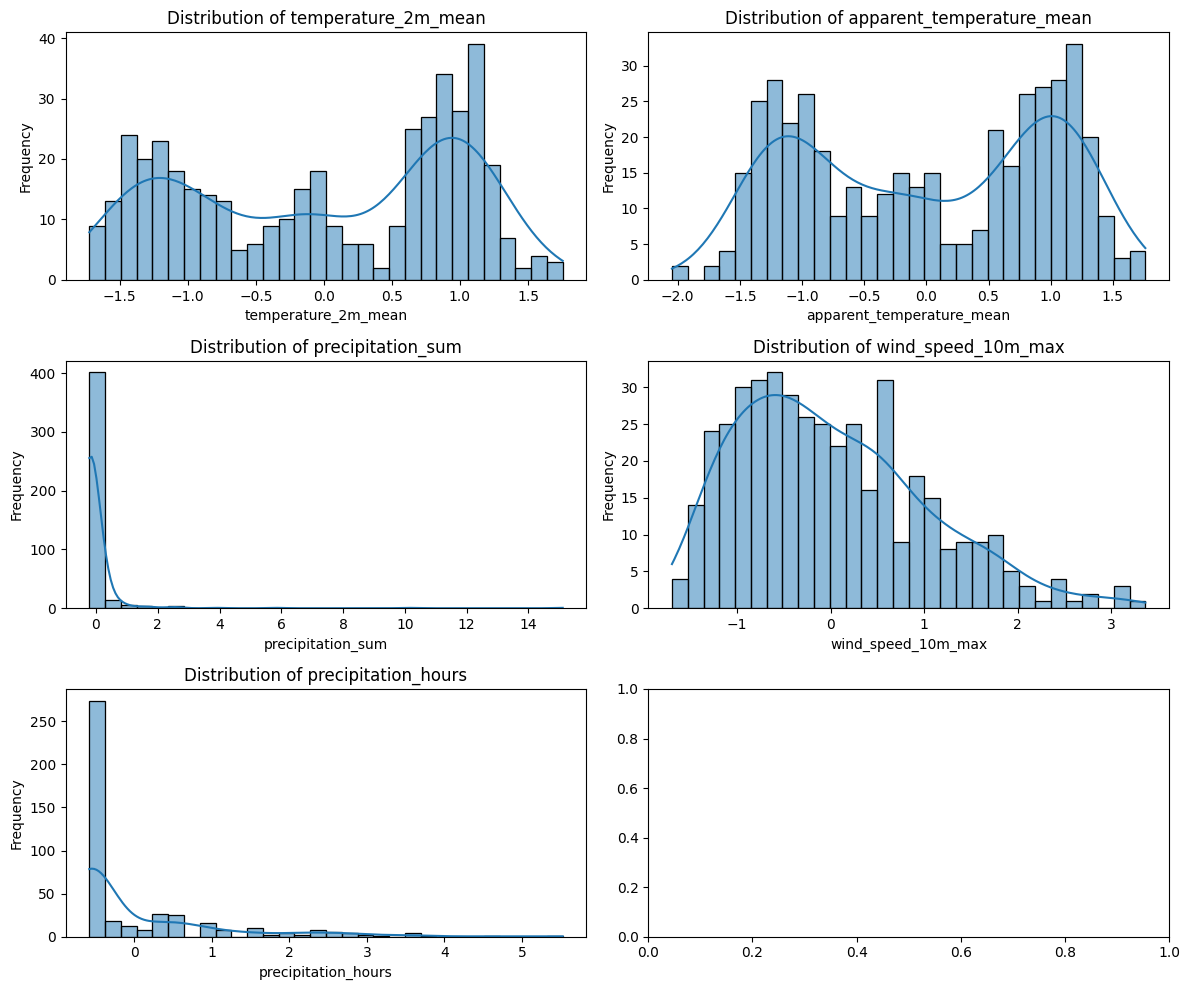

In [5]:

## Continues Columns for a Histogram Plot
continuous_cols = [
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "precipitation_hours"
]

#Initialize the 2x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes = axes.flatten()

#Loop through your columns and assign each to an axis
for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])

    # Use axes[i] to set titles and labels for each specific subplot
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout() #Makes it look pretty
plt.show()

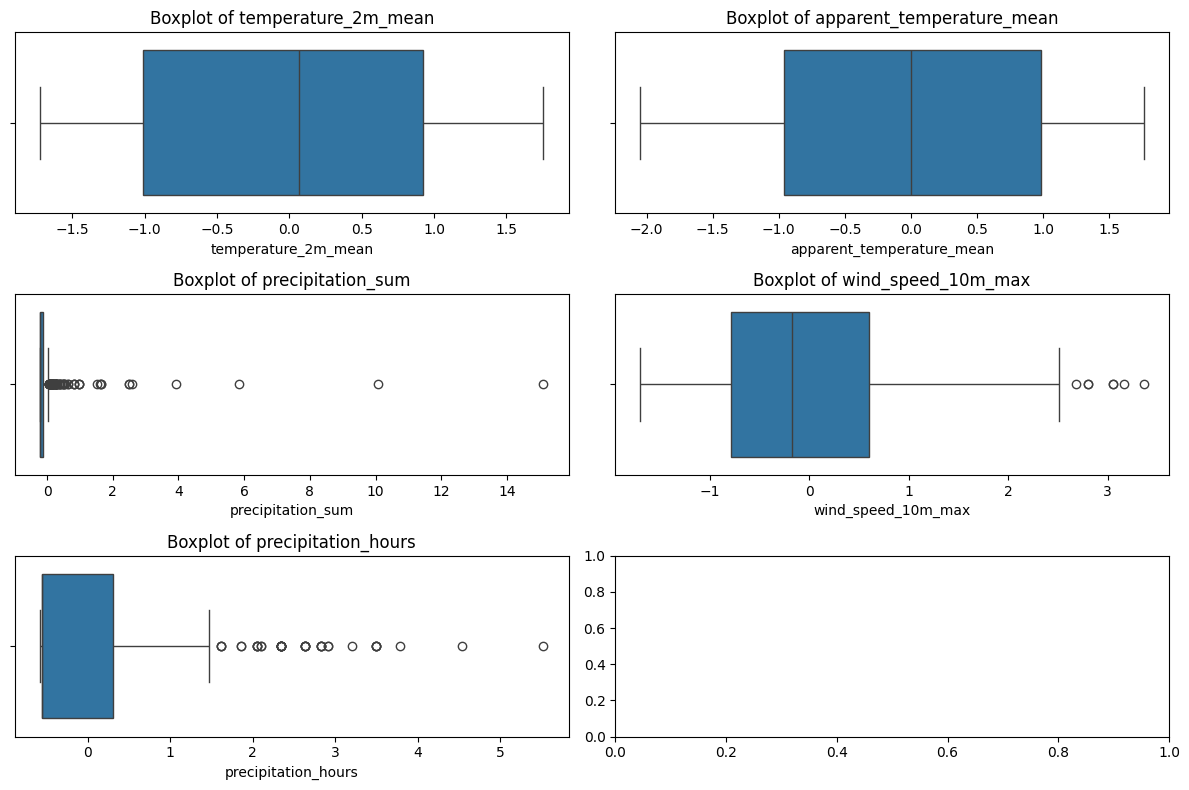

In [6]:
#Initialize the 2x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

axes = axes.flatten()

#Loop through your columns and assign each to an axis
for i, col in enumerate(continuous_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    
    # Use axes[i] to set titles and labels for each specific subplot
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

plt.tight_layout() #Makes it look pretty
plt.show()

In [7]:
df[continuous_cols].agg(["skew", "kurtosis"]).T #Needs to discussed

,skew,kurtosis
temperature_2m_mean,-0.1969,-1.4644
apparent_temperature_mean,-0.0802,-1.4673
precipitation_sum,11.1585,146.9349
wind_speed_10m_max,0.7328,0.1481
precipitation_hours,2.1735,4.9147


### Continuous Analysis 

The histograms for `temperature_2m_mean` & `apparent_temperature_mean` show a bimodal distribution with no visible outliers, which means that linear models might struggle to find a single weight for temperature. To combat this for linear models, it might be better to create a category feature **Summer vs Winter**.

Tree-Based Models and Clustering models can handle the bimodal distribution better and should be able to use the temperature value as is.

The `precipitation_sum`, `percipitation_hours` and `wind_speed_10m_max` histogram and boxplot show that the data is extremely right-skewed, dominated by zero-values and a long tail of significant high-end outliers. It shows that on most of the days there is little to no rain, but there are a number of outliers which signify days with stormy weather. This means that this feature might require further transformation for non-tree-based-models.

**Conclusion:** The temperature features are well-distributed for most ML algorithms; however, the high skewness and outlier density in the precipitation and wind features suggest that tree-based models or targeted feature engineering will be essential to handle the non-normal variance and extreme values effectively.

### Discrete Columns

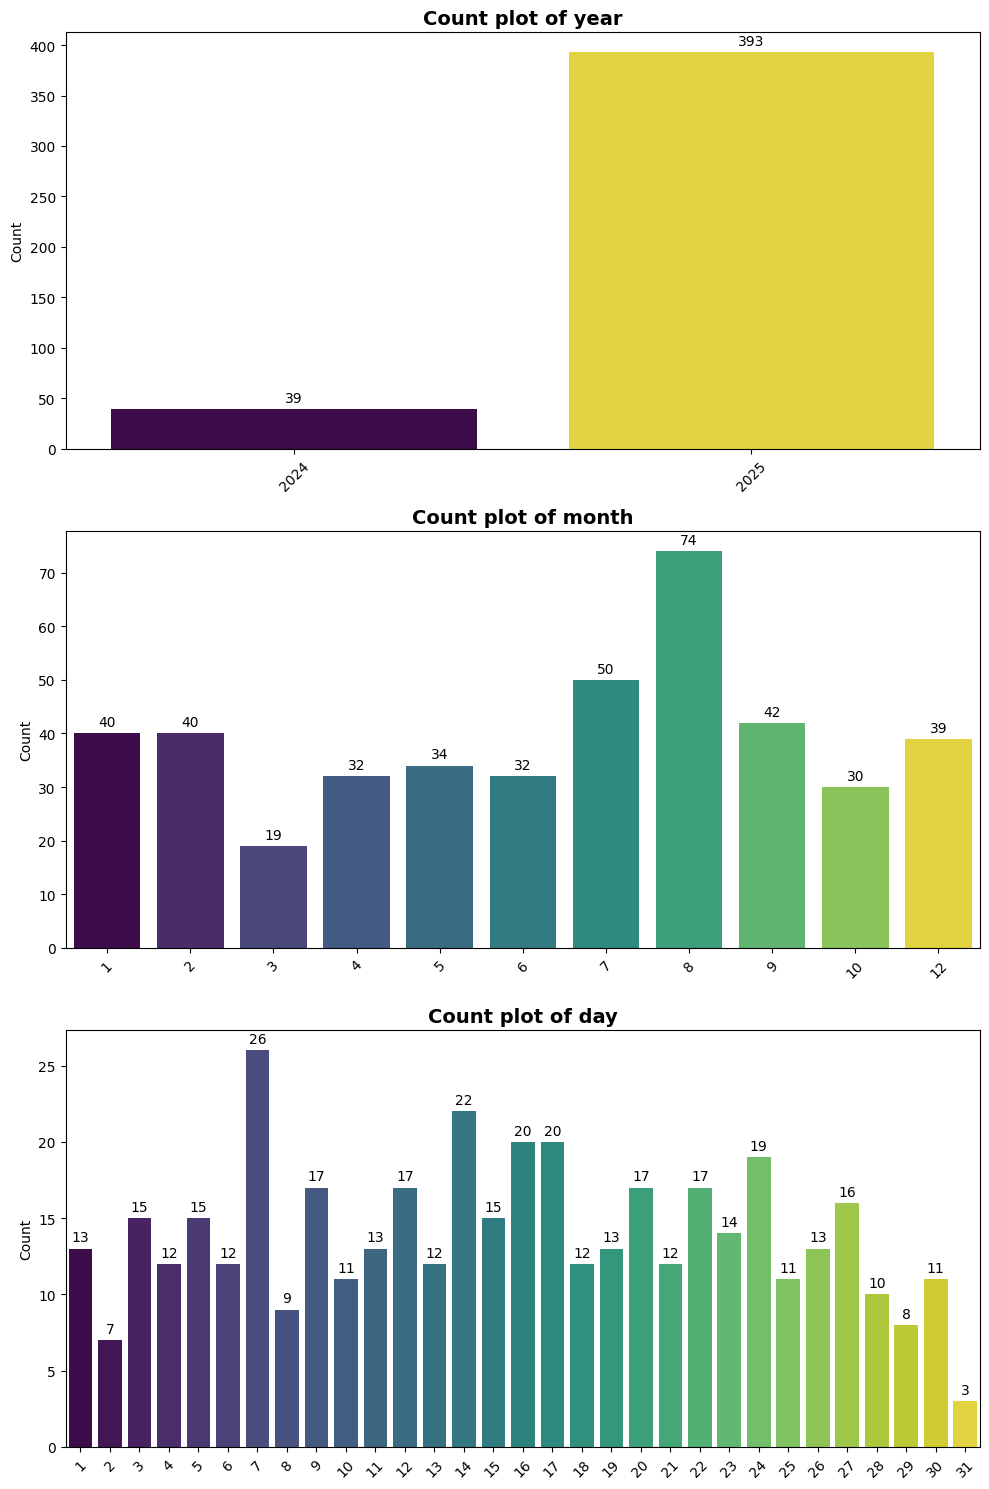

In [8]:
discrete_cols = ["year", "month", "day"]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))

for i, col in enumerate(discrete_cols):
    ax = axes[i]
    
    sns.countplot(
        x=col, 
        data=df, 
        hue=col, 
        legend=False, 
        ax=ax, 
        palette="viridis"
    )
    
    #Loop through all containers to add labels to every bar
    for container in ax.containers:
        ax.bar_label(container, padding=3)
    
    # Formatting
    ax.set_title(f"Count plot of {col}", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel("") 
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Discrete Analysis

From the data count, shows the `year` is heavily skewed towards the most recent year, combined with the low Standard Deviation the value should be disregarded as it is nearly a constant value.


The `month` feature shows a bi-nomial distribution with two peaks around the Summer months and around the Winter Months (December, Janauary and February). It shows a significant peak around August. 

The `Day` plot shows spikes roughly every 7 days (7th, 14th, 21). This might indicate a weekly rhythm, it further supports that this feature should be changed to show the days of the week instead. 

### Binary Columns

In [9]:
#Place the binary features from the dataset in array
binary_cols = [
    "is_holiday",
    "tag_National",
    "tag_Accident",
    "tag_Traffic",
    "tag_Police",
    "tag_Transport"
]

#Calculate the count and percentage of true values
binary_summary = pd.DataFrame({
    "count": df[binary_cols].sum(),
    "percentage": df[binary_cols].mean() * 100
})

binary_summary

,count,percentage
is_holiday,16,3.7037
tag_National,320,74.0741
tag_Accident,333,77.0833
tag_Traffic,247,57.1759
tag_Police,180,41.6667
tag_Transport,32,7.4074


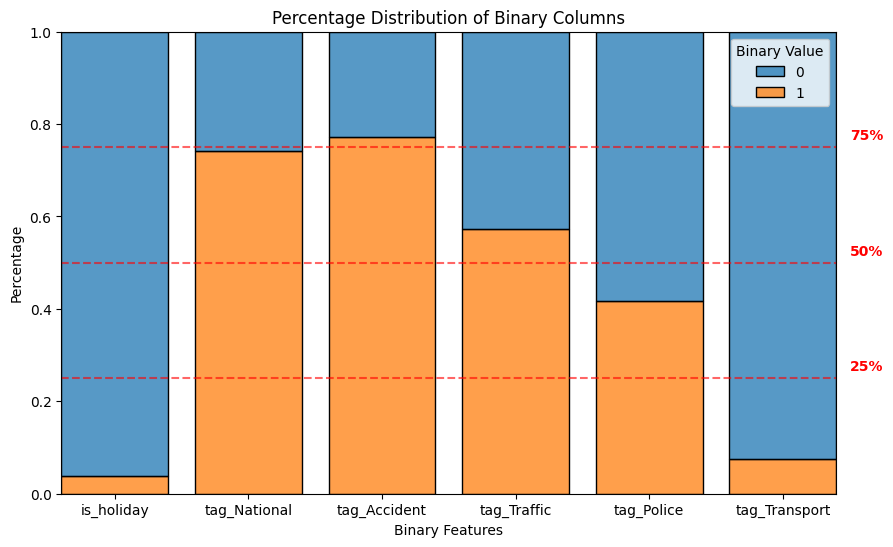

In [10]:
#Reshape the data from wide to long format
df_melted = df[binary_cols].melt(var_name='Column', value_name='Binary Value')

#Plot using a stacked bar chart
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_melted, 
    x='Column', 
    hue='Binary Value', 
    multiple='fill', # This changes the y-axis to percentage (0 to 1.0)
    shrink=0.8
)

#Add dotted lines at 25%, 50%, and 75%
thresholds = [0.25, 0.50, 0.75]
for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    # Adding text label next to the line
    plt.text(x=len(binary_cols)-0.5, y=t+0.01, s=f'{int(t*100)}%', 
             color='red', fontweight='bold', fontsize=10, va='bottom')

plt.title("Percentage Distribution of Binary Columns")
plt.ylabel("Percentage")
plt.xlabel("Binary Features")
plt.show()

### Binary Analysis

The following tags: `tag_National`, `tag_Accident`, `tag_Traffic` and `tag_Police` are high-frequency features which means that the ML models should be able to learn these tags.

The dataset is highly imbalanced for the features `is_holiday` and `tag_Transport`. Techniques like oversampling or specialized loss functions might be required to ensure the model learns to identify these rare events effectively.

### Null Values Analysis

Any `Null` values should have been removed in `1_data_preperation.ipynb`, this is a check to ensure that all the `Null` values were removed.

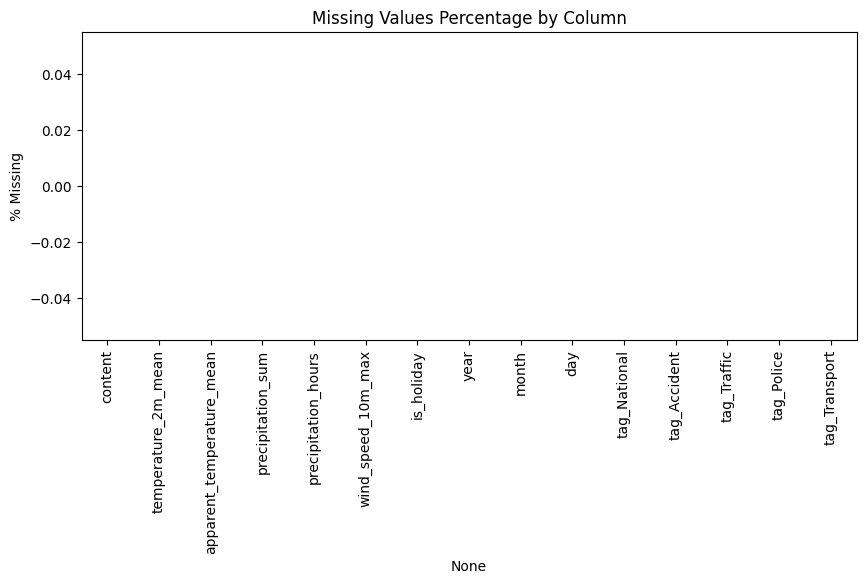

In [11]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

plt.figure(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values Percentage by Column")
plt.ylabel("% Missing")
plt.show()

In [12]:
def univariate_summary(df):
    summary = []

    for col in df.columns:
        summary.append({
            "column": col,
            "dtype": df[col].dtype,
            "missing_%": df[col].isna().mean() * 100,
            "unique": df[col].nunique(),
            "mean": df[col].mean() if pd.api.types.is_numeric_dtype(df[col]) else None,
            "std": df[col].std() if pd.api.types.is_numeric_dtype(df[col]) else None,
            "min": df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else None,
            "max": df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else None
        })

    return pd.DataFrame(summary)

univariate_summary(df)

,column,dtype,missing_%,unique,mean,std,min,max
0,content,object,0.0000,432,NaN,NaN,NaN,NaN
1,temperature_2m_mean,float64,0.0000,175,0.0000,1.0012,-1.7237,1.7555
2,apparent_temperature_mean,float64,0.0000,206,-0.0000,1.0012,-2.0466,1.7616
3,precipitation_sum,float64,0.0000,55,-0.0000,1.0012,-0.2157,15.1102
4,precipitation_hours,float64,0.0000,30,0.0000,1.0012,-0.5798,5.5247
5,wind_speed_10m_max,float64,0.0000,219,-0.0000,1.0012,-1.6981,3.3628
6,is_holiday,int64,0.0000,2,0.0370,0.1891,0.0000,1.0000
7,year,int64,0.0000,2,2024.9097,0.2869,2024.0000,2025.0000
8,month,int64,0.0000,11,6.3773,3.2382,1.0000,12.0000
9,day,int64,0.0000,31,15.4329,8.2276,1.0000,31.0000


## Bivariate Analysis

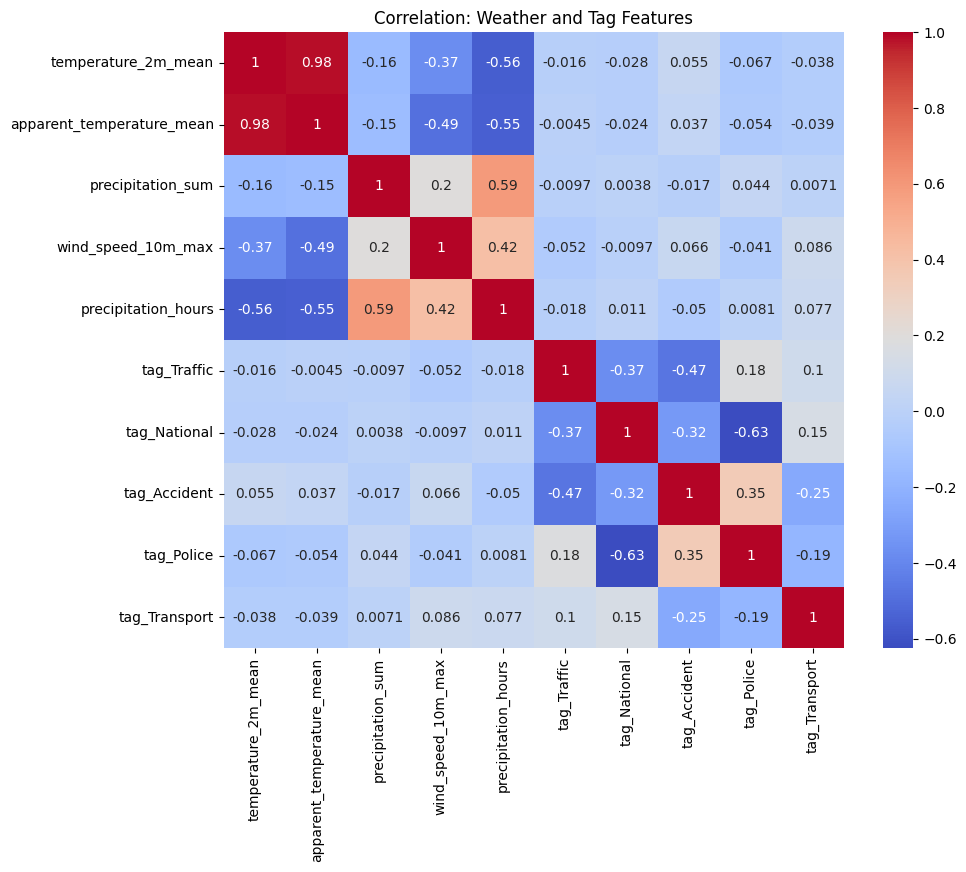

In [13]:
plt.figure(figsize=(10, 8))

#Matrix of Correlation between all the continues features and binary features
corr = df[["temperature_2m_mean", "apparent_temperature_mean", "precipitation_sum", "wind_speed_10m_max",
           "precipitation_hours","tag_Traffic", "tag_National", "tag_Accident","tag_Police","tag_Transport"]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: Weather and Tag Features")
plt.show()

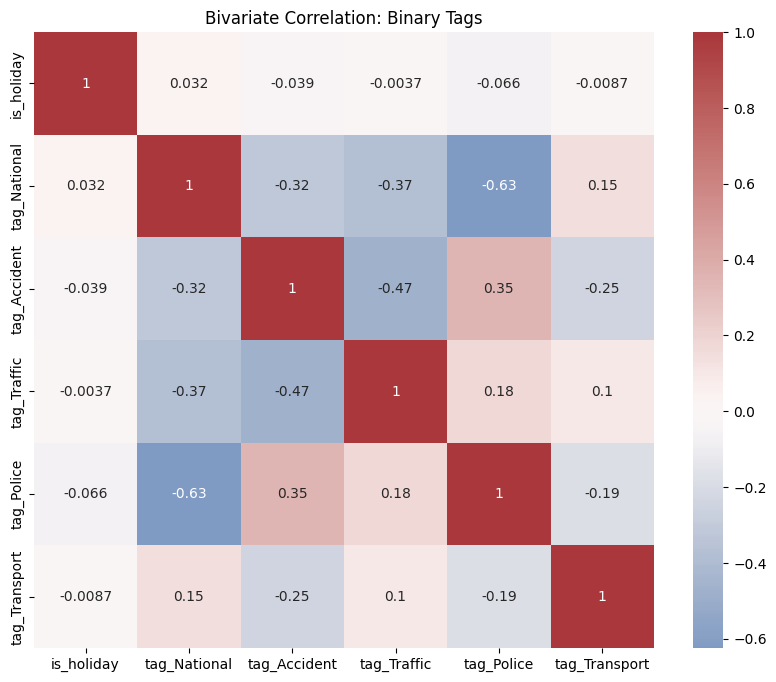

In [14]:
# List of your binary columns
binary_cols = ["is_holiday", "tag_National", "tag_Accident", 
               "tag_Traffic", "tag_Police", "tag_Transport"]

# 1. Calculate the correlation matrix
binary_corr = df[binary_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(binary_corr, annot=True, cmap='vlag', center=0)
plt.title("Bivariate Correlation: Binary Tags")
plt.show()

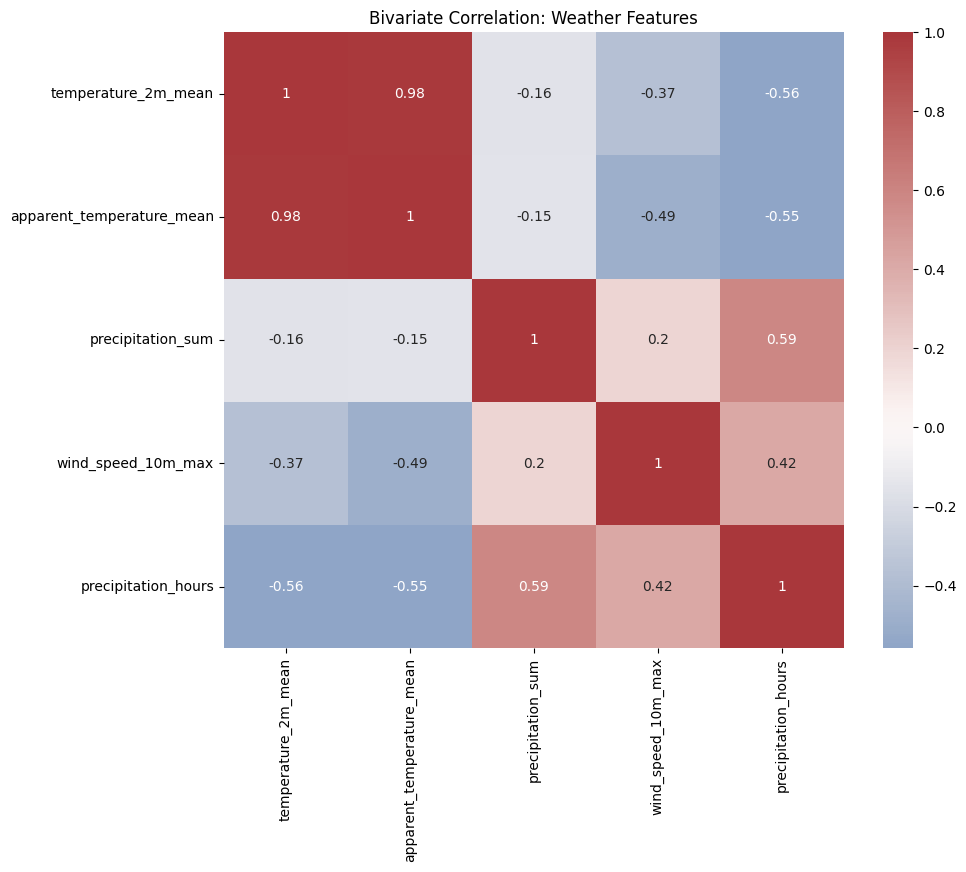

In [15]:
# List of your binary columns
weather_cols = ["temperature_2m_mean", "apparent_temperature_mean", "precipitation_sum", "wind_speed_10m_max",
           "precipitation_hours"]

# 1. Calculate the correlation matrix
weather_cols = df[weather_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(weather_cols, annot=True, cmap='vlag', center=0)
plt.title("Bivariate Correlation: Weather Features")
plt.show()

## Correlation Matrix Analysis

The correlation matrix highlights several strong relationships between features. The most prominent positive correlation is between `mean_2m_temperature` and `mean_apparent_temperature` (≈ 0.98), indicating these variables capture nearly the same thermal signal and one of them can be made redundant. 

Among weather variables, precipitation hours shows a moderate positive correlation with `precipitation_sum` (≈ 0.59) and `wind_speed_10_max` (≈ 0.42), suggesting wetter days tend to be longer-lasting and windier.

In contrast, temperature is moderately negatively correlated with `precipitation_hours` (≈ −0.55 to −0.56), implying cooler Winter periods are associated with more frequent or longer rainfall. 

For tag features, the strongest relationships are negative: `tag_National` and `tag_Police` exhibit a strong negative correlation (≈ −0.63), while `tag_Traffic` is negatively correlated with both `tag_Accident` (≈ −0.47) and `tag_National` (≈ −0.37). 

Overall, weather variables show clearer interdependencies with each other, whereas tag variables mainly exhibit mutual exclusivity rather than strong links to weather conditions.

C:\Users\peljo\AppData\Local\Temp\ipykernel_28920\3520641186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tag_Accident', y='temperature_2m_mean', data=df, palette='Set2')


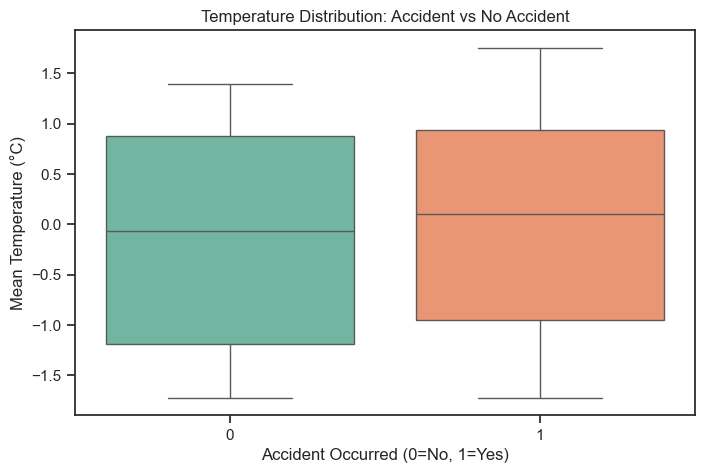

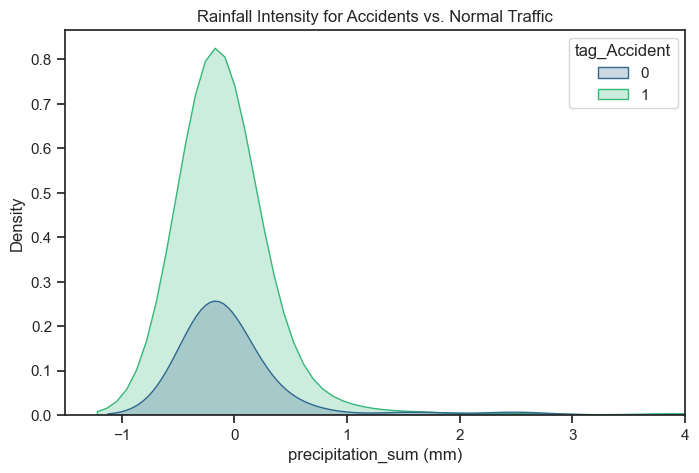

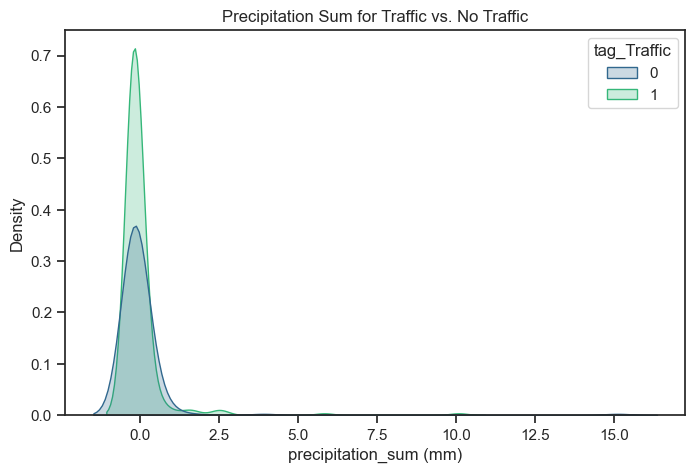

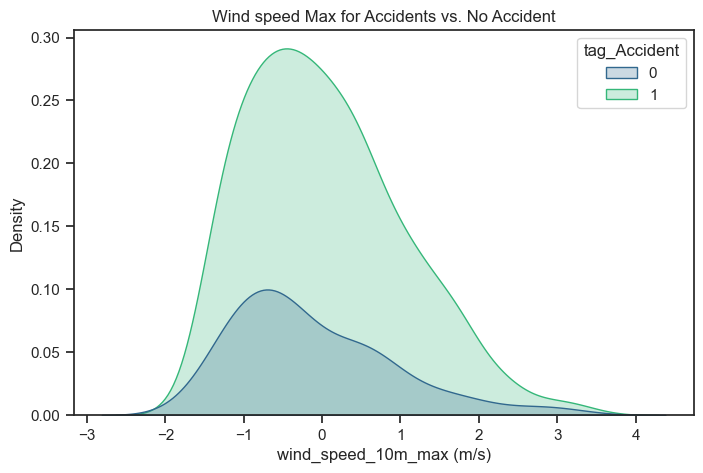

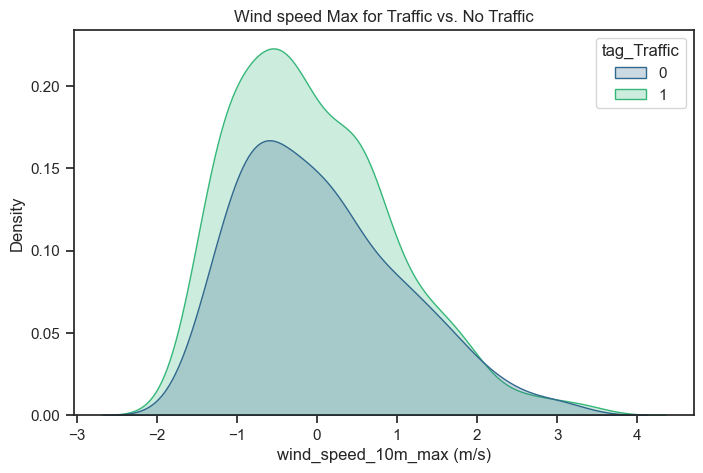

In [33]:
# --- PLOT 1: Box Plot (Temperature vs Accident) ---
plt.figure(figsize=(8, 5))
sns.boxplot(x='tag_Accident', y='temperature_2m_mean', data=df, palette='Set2')
plt.title('Temperature Distribution: Accident vs No Accident')
plt.xlabel('Accident Occurred (0=No, 1=Yes)')
plt.ylabel('Mean Temperature (°C)')
plt.show()

# --- PLOT 2: KDE Plot (Rainfall vs Accident) ---
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='precipitation_sum', hue='tag_Accident', fill=True, palette='viridis')
plt.title('Rainfall Intensity for Accidents vs. Normal Traffic')
plt.xlabel('precipitation_sum (mm)')
plt.xlim(-1.5, 4)  # Sets the X-axis from 0 to 4
plt.show()

# --- PLOT 3: KDE Plot (Rain vs Traffic) ---
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='precipitation_sum', hue='tag_Traffic', fill=True, palette='viridis')
plt.title('Precipitation Sum for Traffic vs. No Traffic')
plt.xlabel('precipitation_sum (mm)')
plt.show()

# --- PLOT 4: KDE Plot (Wind vs Accident) ---
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='wind_speed_10m_max', hue='tag_Accident', fill=True, palette='viridis')
plt.title('Wind speed Max for Accidents vs. No Accident')
plt.xlabel('wind_speed_10m_max (m/s)')
plt.show()

# --- PLOT 5: KDE Plot (Wind vs Traffic) ---
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='wind_speed_10m_max', hue='tag_Traffic', fill=True, palette='viridis')
plt.title('Wind speed Max for Traffic vs. No Traffic')
plt.xlabel('wind_speed_10m_max (m/s)')
plt.show()

# print(f"T-statistic: {t_stat:.4f}")
# print(f"P-value: {p_val:.4f}")

### BiVariate Analysis Conclusion




These weather features are likely not the primary drivers for the "Traffic" or "Accident" tags in this specific dataset. Other factors, such as time of day, road type, or driver behavior, likely carry more predictive weight.

| Weather |Correlation with Accident|Visual Observation|
| ------------- | ---- | -------------- |
|Precipitation|-0.017 (Negligible)|Overlapping distributions; most data at 0 mm.|
|Temperature|0.055 (Negligible)|Boxplots of accidents slightly higher in higher tempratures.|
|Wind Speed|0.066 (Negligible)|Distributions follow the same shape and peak.|

## Multivariate Analysis

Text(0, 0.5, 'Wind Speed (km/h)')

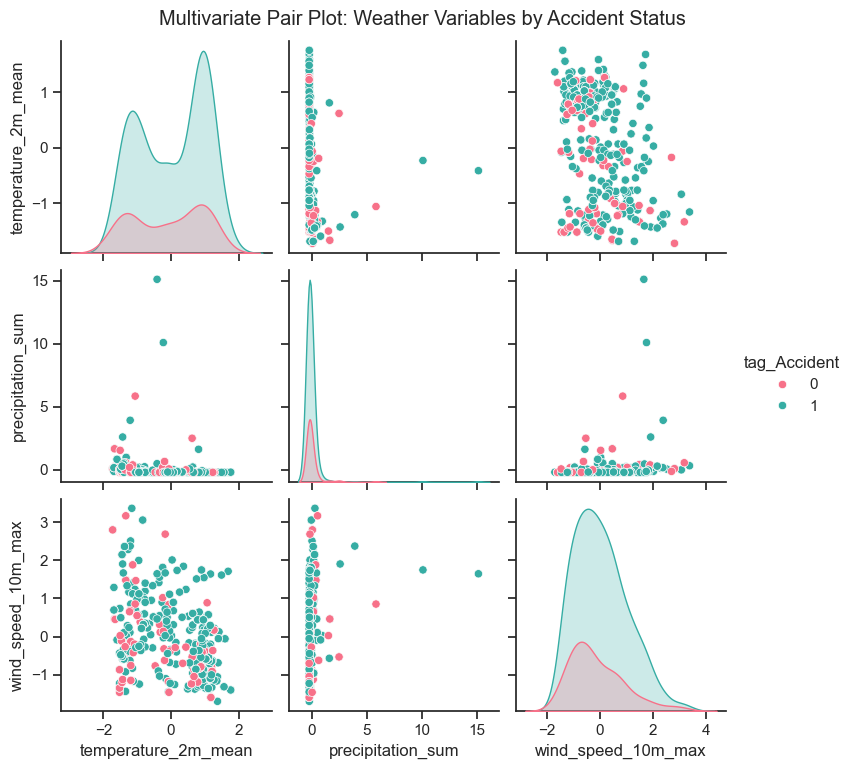

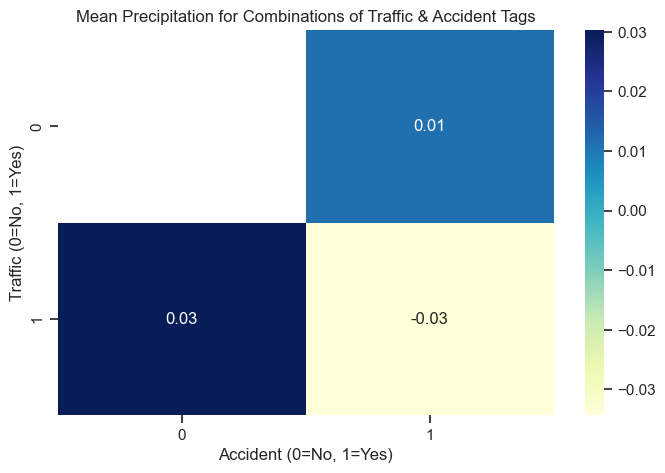

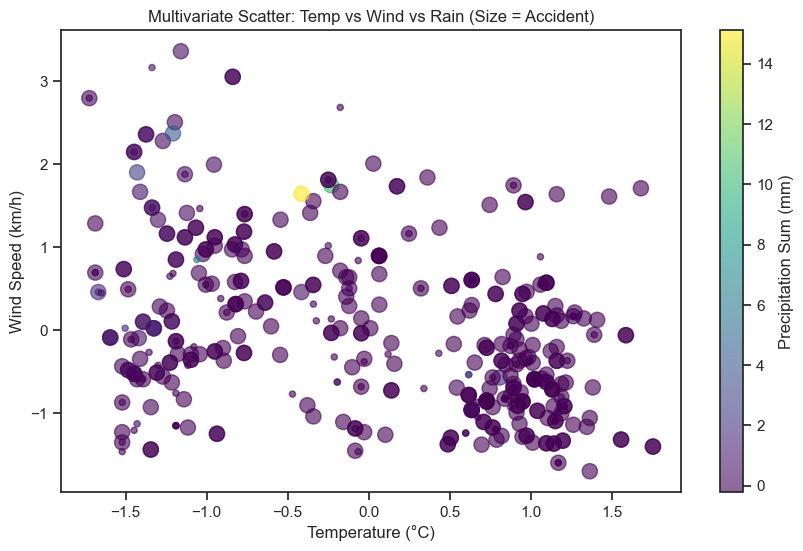

In [ ]:


# --- MULTIVARIATE ANALYSIS 1: Pair Plot ---
# Looking at distributions of weather variables, colored by the Accident category
selected_cols = ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'tag_Accident']
sns.set_theme(style="ticks")
g = sns.pairplot(df[selected_cols], hue='tag_Accident', diag_kind='kde', palette='husl')
g.fig.suptitle('Multivariate Pair Plot: Weather Variables by Accident Status', y=1.02)

# --- MULTIVARIATE ANALYSIS 2: Heatmap of Means (Interaction) ---
# How do 'Traffic' and 'Accident' together relate to 'Precipitation'?
pivot_df = df.pivot_table(values='precipitation_sum', index='tag_Traffic', columns='tag_Accident', aggfunc='mean')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Mean Precipitation for Combinations of Traffic & Accident Tags')
plt.xlabel('Accident (0=No, 1=Yes)')
plt.ylabel('Traffic (0=No, 1=Yes)')

# --- MULTIVARIATE ANALYSIS 3: Bubble Chart (Temp vs Wind vs Rain) ---
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['temperature_2m_mean'], df['wind_speed_10m_max'],
            c=df['precipitation_sum'], s=df['tag_Accident']*100 + 20,
            alpha=0.6, cmap='viridis')
plt.colorbar(scatter, label='Precipitation Sum (mm)')
plt.title('Multivariate Scatter: Temp vs Wind vs Rain (Size = Accident)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Wind Speed (km/h)')

### Multivariate Conclusion 

Overlapping Distributions (Diagonal): The Kernel Density Estimate (KDE) plots on the diagonal show that the "Accident" (green) and "No Accident" (pink) populations have nearly identical distribution shapes for temperature, precipitation, and wind speed. If weather were a strong factor, we would expect to see the green curve shifted toward extreme values (e.g., higher rainfall or lower temperatures).

Uniform Scatter (Off-Diagonal): The scatter plots show that accident data points (green) are dispersed throughout the entire range of weather conditions. There are no visible "clusters" or "hotspots" where accidents are more frequent, such as the combination of high wind and low temperature.

Independence of Variables: Even when weather variables interact (e.g., Temperature vs. Wind Speed), the occurrence of an accident remains random relative to those conditions.